# Unemployment Analysis with Python

## Objective:
To perform exploratory data analysis on unemployment data in India and analyze regional trends, time-based trends, and the impact of COVID-19 on unemployment rates.

In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


## Dataset Loading and Understanding

In [42]:
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## Initial Dataset Inspection


In [43]:
df.shape

(267, 9)

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    str    
 1    Date                                     267 non-null    str    
 2    Frequency                                267 non-null    str    
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    str    
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 18.9 KB


In [45]:
df.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64

In [46]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


## Data Cleaning and Type Conversion

In [47]:
df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.dropna(inplace=True)

df.rename(columns={
    'Estimated Unemployment Rate (%)':'Unemployment_Rate',
    'Estimated Employed':'Employed',
    'Estimated Labour Participation Rate (%)':'Labour_Participation'
}, inplace=True)

df.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation,Region.1,longitude,latitude
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74


In [48]:
df['Region'].unique()

<StringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal']
Length: 27, dtype: str

# Exploratory Data Analysis

State-wise Average Unemployment Rate

In [49]:
state_average = df.groupby('Region')['Unemployment_Rate'].mean()

state_average.sort_values(ascending=False)

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Unemployment_Rate, dtype: float64

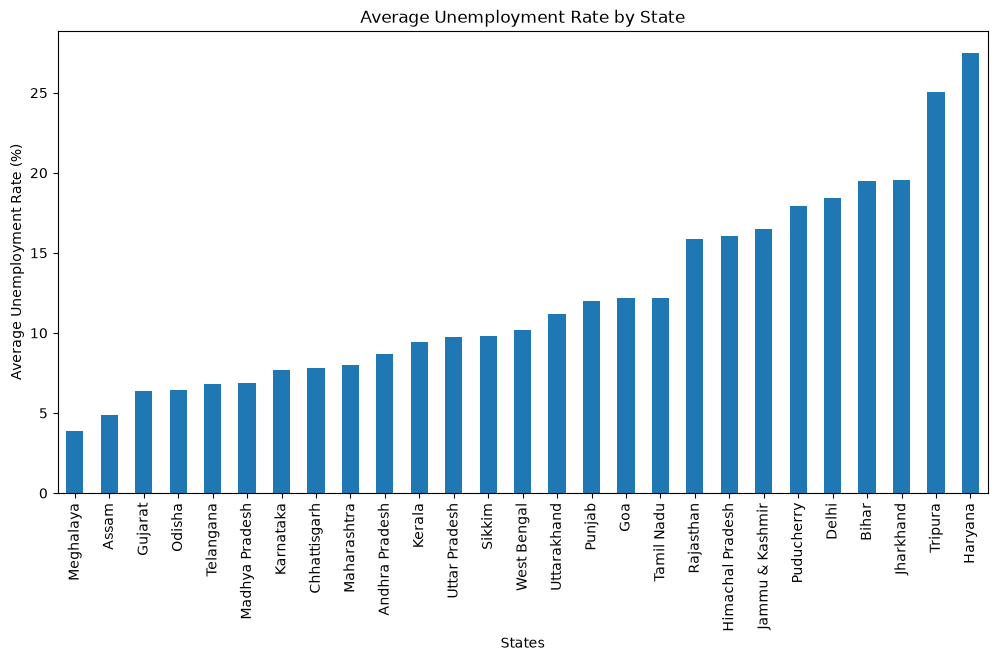

In [50]:
plt.figure(figsize=(12,6))

state_average.sort_values().plot(kind='bar')

plt.title("Average Unemployment Rate by State")

plt.xlabel("States")

plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=90)

plt.show()

### Observation

The graph shows variations in unemployment rates across Indian states.

## Month-wise Unemployment Trend

In [51]:
df['Month'] = df['Date'].dt.month

monthly_trend = df.groupby('Month')['Unemployment_Rate'].mean()

monthly_trend

Month
1      9.196538
2      9.266154
3     10.782593
4     22.236154
5     23.244444
6     10.911111
7      9.834444
8     10.313333
9      8.705926
10     8.026296
Name: Unemployment_Rate, dtype: float64

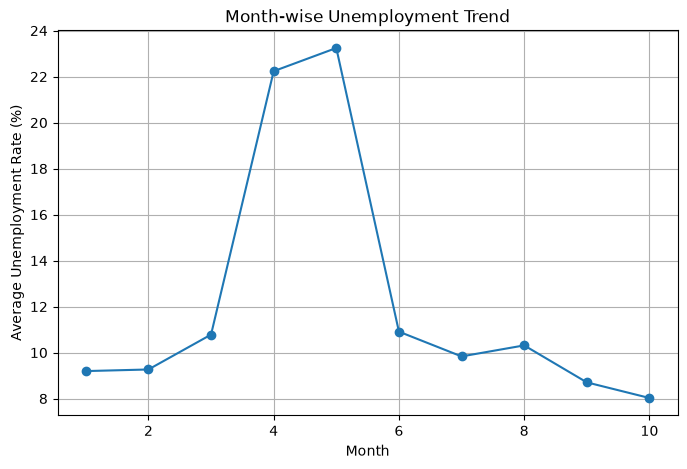

In [52]:
plt.figure(figsize=(8,5))

plt.plot(
    monthly_trend.index,
    monthly_trend.values,
    marker='o'
)

plt.title("Month-wise Unemployment Trend")

plt.xlabel("Month")

plt.ylabel("Average Unemployment Rate (%)")

plt.grid()

plt.show()

### Observation

The monthly analysis shows how unemployment changed over time.

## Time-Series Analysis of Three States

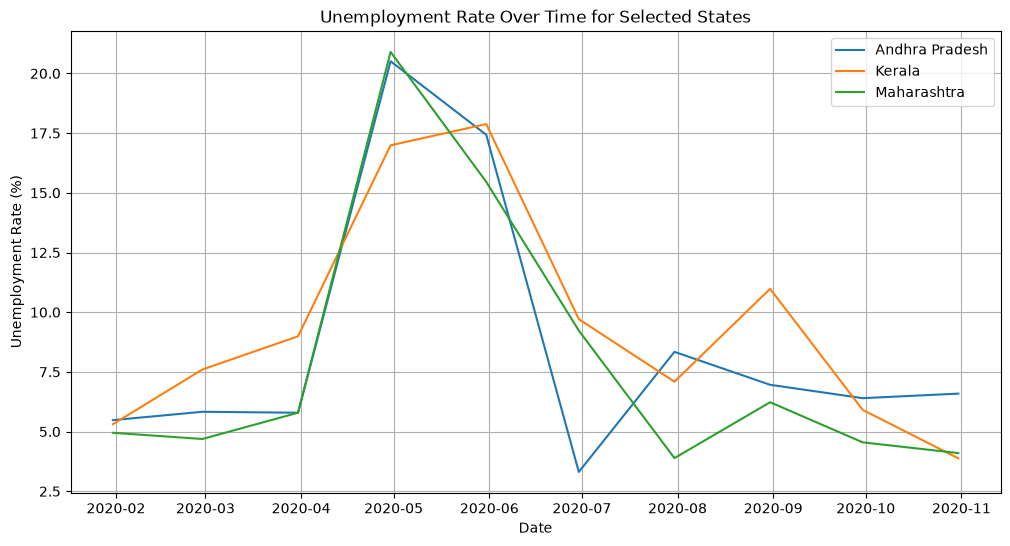

In [53]:
plt.figure(figsize=(12,6))

selected_states = [
    'Andhra Pradesh',
    'Kerala',
    'Maharashtra'
]


for state in selected_states:

    state_data = df[df['Region']==state]

    plt.plot(
        state_data['Date'],
        state_data['Unemployment_Rate'],
        label=state
    )


plt.title("Unemployment Rate Over Time for Selected States")

plt.xlabel("Date")

plt.ylabel("Unemployment Rate (%)")

plt.legend()

plt.grid()

plt.show()

### Observation

The time-series graph compares unemployment trends among three states and highlights changes during the COVID-19 period.

## Top 10 States with Highest Average Unemployment Rate

In [54]:
top10_states = (
    df.groupby('Region')['Unemployment_Rate']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top10_states

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Unemployment_Rate, dtype: float64

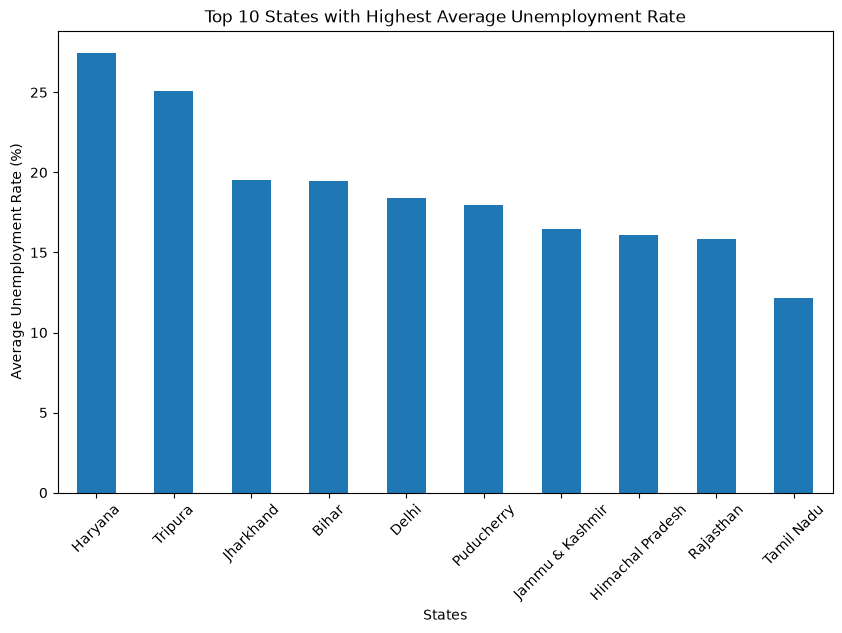

In [55]:
plt.figure(figsize=(10,6))

top10_states.plot(kind='bar')

plt.title("Top 10 States with Highest Average Unemployment Rate")

plt.xlabel("States")

plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

### Observation

The chart identifies the top 10 states with the highest average unemployment rate during the given period.

## Correlation Analysis

In [56]:
correlation = df[
[
'Unemployment_Rate',
'Employed',
'Labour_Participation'
]
].corr()


correlation

,Unemployment_Rate,Employed,Labour_Participation
Unemployment_Rate,1.000000,-0.245176,-0.073540
Employed,-0.245176,1.000000,-0.047948
Labour_Participation,-0.073540,-0.047948,1.000000


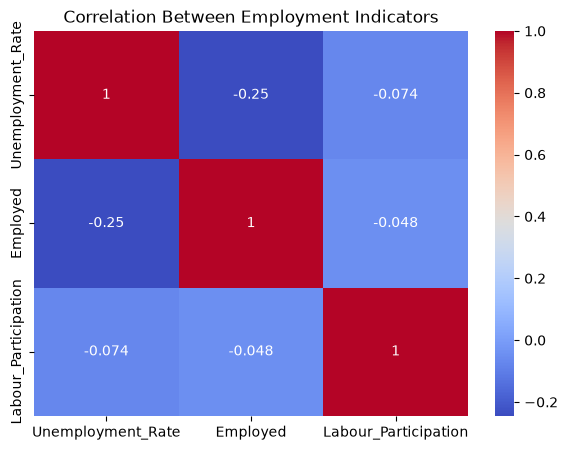

In [57]:
plt.figure(figsize=(7,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Employment Indicators")

plt.show()

### Observation

The heatmap represents the relationship between unemployment rate, employment level, and labour participation rate.

## Pre-COVID vs Post-COVID Analysis

In [58]:
pre_covid = df[df['Date'] < '2020-03-01']

post_covid = df[df['Date'] >= '2020-03-01']


pre_covid_mean = pre_covid['Unemployment_Rate'].mean()

post_covid_mean = post_covid['Unemployment_Rate'].mean()


print("Pre-COVID Average Unemployment Rate:",
      pre_covid_mean)

print("Post-COVID Average Unemployment Rate:",
      post_covid_mean)

Pre-COVID Average Unemployment Rate: 9.231346153846154
Post-COVID Average Unemployment Rate: 12.963860465116278


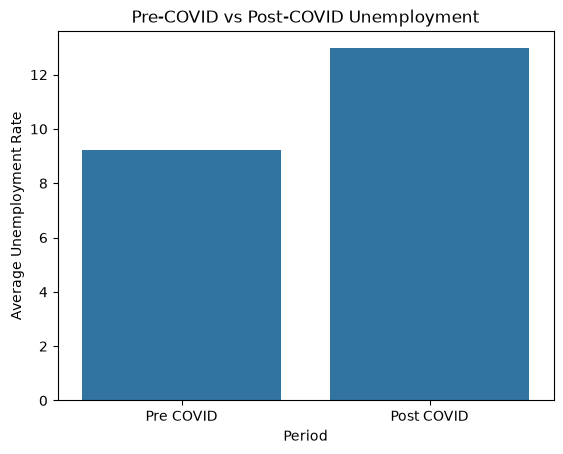

In [59]:
covid_comparison = pd.DataFrame({

    "Period":
    [
        "Pre COVID",
        "Post COVID"
    ],

    "Average Unemployment Rate":
    [
        pre_covid_mean,
        post_covid_mean
    ]

})


sns.barplot(
    data=covid_comparison,
    x="Period",
    y="Average Unemployment Rate"
)


plt.title("Pre-COVID vs Post-COVID Unemployment")

plt.show()

### Observation

The comparison shows the change in unemployment rate before and after COVID-19. The pandemic period affected employment conditions significantly.

# Conclusion

- Unemployment rates differed across Indian states.
- Time-based analysis showed changes in unemployment trends.
- COVID-19 had a major impact on unemployment levels.
- Data visualization helped identify regional and temporal patterns.